# Импорт библиотек и установка констант

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# Модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Метрики качества
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')


In [9]:
# Настройки для текущей задачи. Допустимые варианты:
# 'class_IC50_above_med', 'class_CC50_above_med', 'class_SI_above_med', 'class_SI_above_8'
TARGET_CLASS_COL = 'class_CC50_above_med'  
RANDOM_STATE = 42


# Загрузка данных и разделение

In [10]:
# Загружаем очищенный датасет
df = pd.read_csv('cleaned_chemical_data.csv')

# Определяем список колонок, которые НЕ являются признаками
exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log10_SI',
                'class_IC50_above_med', 'class_CC50_above_med', 'class_SI_above_med', 'class_SI_above_8', 'log10_SI']

# Разделяем на X и y
X = df[[col for col in df.columns if col not in exclude_cols]]
y = df[TARGET_CLASS_COL]

# Считаем балансировочный вес для XGBoost на случай дисбаланса
ratio = (len(y) - y.sum()) / y.sum()

# Разделение 80/20 строго со стратификацией!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Пропорции классов в Train: {np.bincount(y_train) / len(y_train) * 100}%")
print(f"Пропорции классов в Test : {np.bincount(y_test) / len(y_test) * 100}%")


Task was destroyed but it is pending!
task: <Task pending name='Task-105' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/itj/anaconda3/envs/edu/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-106' coro=<Kernel.shell_main() running at /home/itj/anaconda3/envs/edu/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/itj/anaconda3/envs/edu/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-106' coro=<Kernel.shell_main() running at /home/itj/anaconda3/envs/edu/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Пропорции классов в Train: [49.92199688 50.07800312]%
Пропорции классов в Test : [50.31055901 49.68944099]%


# Настройка параметров и обучение модели

In [11]:
models_and_params = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000),
        'params': {
            'classifier__C': [0.01, 0.1, 1.0, 10.0]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [5, 10, None]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight=ratio, eval_metric='logloss'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.05, 0.1]
        }
    }
}


In [12]:
best_models = {}
results_list = []

for model_name, config in models_and_params.items():
    print(f"Обучение и оптимизация {model_name}...")
    
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', config['model'])
    ])
    
    # Оптимизируем по F1-score (для защиты от дисбаланса классов)
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_pipe = grid_search.best_estimator_
    best_models[model_name] = best_pipe
    
    # Предсказания классов и вероятностей
    y_pred = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
    
    # Расчет полного спектра метрик
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    results_list.append({
        'Модель': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': pr_auc
    })

df_results = pd.DataFrame(results_list)
display(df_results.sort_values(by='F1-Score', ascending=False).round(3))


Обучение и оптимизация LogisticRegression...
Обучение и оптимизация RandomForest...
Обучение и оптимизация XGBoost...


,Модель,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
1,RandomForest,0.733,0.740,0.712,0.726,0.817,0.802
0,LogisticRegression,0.714,0.718,0.700,0.709,0.792,0.767
2,XGBoost,0.696,0.701,0.675,0.688,0.794,0.778


# Визуализация

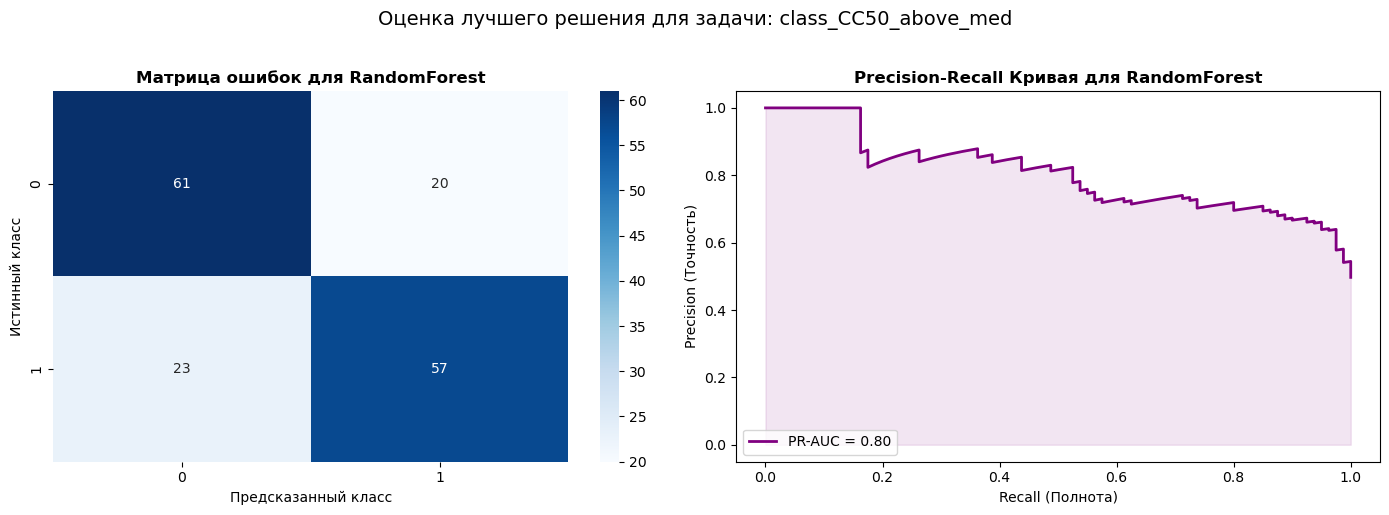

In [13]:
# Находим лучшую модель по F1-Score
best_model_name = df_results.sort_values(by='F1-Score', ascending=False).iloc[0]['Модель']
best_pipeline = best_models[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Отрисовка Матрицы ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Матрица ошибок для {best_model_name}', fontweight='bold')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

# 2. Отрисовка Precision-Recall кривой (PR-AUC)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba_best)
pr_auc = auc(recall_vals, precision_vals)

axes[1].plot(recall_vals, precision_vals, color='purple', lw=2, label=f'PR-AUC = {pr_auc:.2f}')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='purple')
axes[1].set_title(f'Precision-Recall Кривая для {best_model_name}', fontweight='bold')
axes[1].set_xlabel('Recall (Полнота)')
axes[1].set_ylabel('Precision (Точность)')
axes[1].legend(loc='lower left')

plt.suptitle(f'Оценка лучшего решения для задачи: {TARGET_CLASS_COL}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# Анализ результатов классификации pCC50 (Превышение медианы выборки)

На основе тестирования моделей для задачи бинарной классификации цитотоксичности сделаны следующие выводы:

1. **Стабильный лидер:** Модель **RandomForest** сохраняет наилучшее качество предсказания ($F1\text{-}Score \approx 0.73$, $ROC\text{-}AUC \approx 0.82$, $PR\text{-}AUC \approx 0.80$). Алгоритм эффективно использует комбинации топологических и зарядовых свойств для детекции повышенной токсичности соединений.
2. **Особенность признаков:** В отличие от задачи активности, в задаче токсичности **LogisticRegression** продемонстрировала высокую конкурентоспособность, опередив XGBoost по метрике F1-score ($0.709$ против $0.688$). Это указывает на то, что базовые драйверы токсичности (такие как общая полярность или молекулярная масса) вносят весомый вклад в линейном виде, что позволяет простым моделям показывать робастный результат.
